Selection_regret_ftse

In [30]:

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import KFold

from purgedcv import PurgedGroupKFold, WalkForwardSplit

_project_root = Path.cwd().parent
sys.path.insert(0, str(_project_root))
sys.path.insert(0, str(_project_root / "src"))






In [23]:
# FTSE 100 tickers (using yfinance's .L suffix for London Stock Exchange)
tickers = [
    "AZN.L", "HSBA.L", "SHEL.L", "ULVR.L", "BP.L", "GSK.L", "DGE.L",
    "RIO.L", "BATS.L", "REL.L", "LSEG.L", "NG.L", "GLEN.L", "AAL.L",
    "BARC.L", "LLOY.L", "VOD.L", "PRU.L", "CPG.L", "TSCO.L", "IMB.L",
    "NWG.L", "STAN.L", "AV.L", "SSE.L", "RKT.L", "BT-A.L", "SGE.L",
    "SMIN.L", "WTB.L"
]

# Download FTSE data
start_date = "2018-01-01"
end_date = "2024-12-31"

print(f"Downloading data for {len(tickers)} FTSE stocks from {start_date} to {end_date}...")
data_dict = {}
for ticker in tickers:
    try:
        df = yf.download(ticker, start=start_date, end=end_date, progress=False)
        if len(df) > 0:
            df['ticker'] = ticker
            data_dict[ticker] = df
            print(f"  {ticker}: {len(df)} rows")
    except Exception as e:
        print(f"  {ticker}: FAILED ({e})")

data = pd.concat([df.reset_index() for df in data_dict.values()], ignore_index=True)
frames = []
for ticker, df in data_dict.items():
    tmp = df.reset_index()
    if isinstance(tmp.columns, pd.MultiIndex):
        tmp.columns = [c[-1] if isinstance(c, tuple) else c for c in tmp.columns]

    if "Date" not in tmp.columns and "index" in tmp.columns:
        tmp = tmp.rename(columns={"index": "Date"})

    tmp["ticker"] = ticker
    keep = [c for c in ["Date", "Open", "High", "Low", "Close", "Volume", "ticker"] if c in tmp.columns]
    frames.append(tmp[keep])

data = pd.concat(frames, ignore_index=True)

def norm_yf_col(col):
    if isinstance(col, tuple):
        parts = [str(p).strip() for p in col if str(p).strip() != ""]
        for p in reversed(parts):
            if p in {"Date", "Open", "High", "Low", "Close", "Volume", "ticker"}:
                return p
        return parts[-1] if parts else ""
    return str(col)

frames = []
for ticker, df_ in data_dict.items():
    tmp = df_.copy().reset_index()
    if isinstance(tmp.columns, pd.MultiIndex):
        tmp.columns = pd.Index([norm_yf_col(c) for c in tmp.columns])

    if "Date" not in tmp.columns and "index" in tmp.columns:
        tmp = tmp.rename(columns={"index": "Date"})

    tmp["ticker"] = ticker
    keep = [c for c in ["Date", "Open", "High", "Low", "Close", "Volume", "ticker"] if c in tmp.columns]
    frames.append(tmp[keep])

data = pd.concat(frames, ignore_index=True)
data["Date"] = pd.to_datetime(data["Date"])
data = data.sort_values(['Date', 'ticker']).reset_index(drop=True)

print(f"\nCombined dataset: {len(data)} rows, {data['ticker'].nunique()} tickers")
print(f"Date range: {data['Date'].min().date()} to {data['Date'].max().date()}")
print(f"\nFirst few rows:\n{data.head()}")


bday_index = pd.bdate_range(
    start=data['Date'].min(),
    end=data['Date'].max() + pd.Timedelta(days=30)  # add buffer to handle 5-day lookahead
)

# For each unique date in our data, find the date 5 business days later
eval_times_dict = {}
for date in sorted(data['Date'].unique()):
    try:
        # Find the position of this date in the business-day index
        pos = bday_index.get_loc(date)
        # 5 business days ahead = current position + 5
        if pos + 5 < len(bday_index):
            eval_times_dict[date] = bday_index[pos + 5]
        else:
            eval_times_dict[date] = None  # can't look 5 days ahead (data ends here)
    except KeyError:
        # This date isn't in the business-day index (shouldn't happen with yfinance data)
        eval_times_dict[date] = None

# Map evaluation_times to each row
data['evaluation_times'] = data['Date'].map(eval_times_dict)

# Check: how many rows have no valid evaluation_times?
missing = data['evaluation_times'].isna().sum()
print(f"Rows without valid evaluation_times (likely at data end): {missing}")
print(f"Keeping {len(data) - missing} rows with complete 5-day windows")

# Drop rows without evaluation_times (they can't have a complete label)
data = data[data['evaluation_times'].notna()].reset_index(drop=True)

print("\nSample of dates with evaluation_times:")
print(data[['Date', 'ticker', 'evaluation_times']].head(10))


# Calculate daily returns (this is the simplest useful feature set)
data = data.sort_values(['ticker', 'Date']).reset_index(drop=True)
data['returns'] = data.groupby('ticker')['Close'].pct_change()

# Forward return over 5 days (the label)
# For each row, look up the close price at its evaluation_times date
eval_closes = data.set_index(['ticker', 'Date'])['Close'].to_dict()

def get_forward_return(row):
    """Get the 5-day forward return using evaluation_times."""
    try:
        # Close price today
        today_close = row['Close']
        # Close price 5 business days from now
        future_key = (row['ticker'], row['evaluation_times'])
        if future_key in eval_closes:
            future_close = eval_closes[future_key]
            return (future_close / today_close) - 1
    except(KeyError, TypeError):
        pass
    return np.nan

data['forward_return'] = data.apply(get_forward_return, axis=1)

# Simple features (you can expand these later)
data['returns_5d'] = data.groupby('ticker')['returns'].rolling(5).mean().reset_index(0, drop=True)
data['returns_20d'] = data.groupby('ticker')['returns'].rolling(20).mean().reset_index(0, drop=True)
data['volatility_20d'] = data.groupby('ticker')['returns'].rolling(20).std().reset_index(0, drop=True)

# Drop rows with NaN features or target
data = data.dropna(subset=['forward_return', 'returns_5d', 'returns_20d', 'volatility_20d']).reset_index(drop=True)

print(f"After dropping incomplete rows: {len(data)} rows")
print("\nFeatures and target:")
print(data[['Date', 'ticker', 'returns_5d', 'returns_20d', 'volatility_20d', 'forward_return']].head(10))
print("\nTarget (forward_return) statistics:")
print(data['forward_return'].describe())

  AZN.L: 1767 rows
  HSBA.L: 1767 rows
  SHEL.L: 1767 rows
  ULVR.L: 1767 rows
  BP.L: 1767 rows
  GSK.L: 1767 rows
  DGE.L: 1766 rows
  RIO.L: 1767 rows
  BATS.L: 1767 rows
  REL.L: 1767 rows
  LSEG.L: 1767 rows
  NG.L: 1767 rows
  GLEN.L: 1766 rows
  AAL.L: 1767 rows
  BARC.L: 1767 rows
  LLOY.L: 1767 rows
  VOD.L: 1767 rows
  PRU.L: 1767 rows
  CPG.L: 1767 rows
  TSCO.L: 1767 rows
  IMB.L: 1766 rows
  NWG.L: 1767 rows
  STAN.L: 1767 rows
  AV.L: 1767 rows
  SSE.L: 1767 rows
  RKT.L: 1767 rows
  BT-A.L: 1767 rows
  SGE.L: 1767 rows
  SMIN.L: 1767 rows
  WTB.L: 1767 rows

Combined dataset: 53007 rows, 30 tickers
Date range: 2018-01-02 to 2024-12-30

First few rows:
        Date         Open         High          Low        Close    Volume  \
0 2018-01-02  1515.715285  1550.715576  1496.464833  1550.715576   5579235   
1 2018-01-02   496.558484   499.891118   491.069480   492.833832   6074039   
2 2018-01-02  5114.170777  5146.096931  5071.270007  5093.219238   2350718   
3 2018-01-02 

In [24]:
# Choose holdout start date (last ~12 months
# # This data will be completely untouched during CV, only used once at the very end
holdout_start_date = pd.Timestamp('2024-01-01')

# Split
model_selection_data = data[data['Date'] < holdout_start_date].copy()
holdout_data = data[data['Date'] >= holdout_start_date].copy()

print(f"Model selection data: {len(model_selection_data)} rows, {model_selection_data['Date'].min().date()} to {model_selection_data['Date'].max().date()}")
print(f"Holdout data: {len(holdout_data)} rows, {holdout_data['Date'].min().date()} to {holdout_data['Date'].max().date()}")

# Remove training labels that cross the holdout boundary
# (If a row's evaluation_times is in the holdout period, drop it from model_selection)
model_selection_data = model_selection_data[
    model_selection_data['evaluation_times'] < holdout_start_date
].reset_index(drop=True)

print(f"After removing labels crossing holdout boundary: {len(model_selection_data)} rows")

# Prepare X, y for CV
X = model_selection_data[['returns_5d', 'returns_20d', 'volatility_20d']]
y = (model_selection_data['forward_return'] > 0).astype(int)  # Binary: positive return = 1, else 0
dates = model_selection_data['Date'].values
tickers = model_selection_data['ticker'].values

print(f"\nTarget distribution (% positive returns): {y.mean():.2%}")
print(f"Feature matrix shape: {X.shape}")
print(f"Dates shape: {dates.shape}, Tickers shape: {tickers.shape}")

# Same for holdout
X_holdout = holdout_data[['returns_5d', 'returns_20d', 'volatility_20d']]
y_holdout = (holdout_data['forward_return'] > 0).astype(int)

print(f"\nHoldout target distribution: {y_holdout.mean():.2%}")

Model selection data: 43500 rows, 2018-01-30 to 2023-12-29
Holdout data: 7284 rows, 2024-01-02 to 2024-12-23
After removing labels crossing holdout boundary: 43410 rows

Target distribution (% positive returns): 51.63%
Feature matrix shape: (43410, 3)
Dates shape: (43410,), Tickers shape: (43410,)

Holdout target distribution: 52.97%


In [25]:


from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Prepare data for purgedcv
# purgedcv needs: prediction_times (when we make prediction), evaluation_times (when label is known)
prediction_times = pd.Series(model_selection_data['Date'].values, index=range(len(model_selection_data)))
evaluation_times = pd.Series(model_selection_data['evaluation_times'].values, index=range(len(model_selection_data)))

# Also need to group by date for PurgedGroupKFold (to keep same-day rows together)
groups = pd.Series(model_selection_data['Date'].values, index=range(len(model_selection_data)))

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Store results for each CV strategy
cv_results = []

print("=" * 80)
print("BASELINE COMPARISON: Testing for look-ahead leakage")
print("=" * 80)

# 1. Naive KFold(shuffle=False) — contiguous folds, will leak
print("\n1. KFold(shuffle=False) — contiguous folds (LEAKS via overlapping labels)")
cv_naive = KFold(n_splits=5, shuffle=False)
aucs_naive = []
for fold, (train_idx, test_idx) in enumerate(cv_naive.split(X_scaled)):
    model = LogisticRegression(max_iter=1000)
    model.fit(X_scaled.iloc[train_idx], y.iloc[train_idx])
    y_pred = model.predict_proba(X_scaled.iloc[test_idx])[:, 1]
    auc = roc_auc_score(y.iloc[test_idx], y_pred)
    aucs_naive.append(auc)
    print(f"  Fold {fold}: AUC = {auc:.4f}")

cv_results.append({
    'method': 'KFold(shuffle=False)',
    'mean_auc': np.mean(aucs_naive),
    'std_auc': np.std(aucs_naive),
})

# 2. KFold(shuffle=True) — shuffled, still leaks via overlapping labels
print("\n2. KFold(shuffle=True) — shuffled folds (STILL LEAKS via forward-looking labels)")
cv_shuffled = KFold(n_splits=5, shuffle=True, random_state=42)
aucs_shuffled = []
for fold, (train_idx, test_idx) in enumerate(cv_shuffled.split(X_scaled)):
    model = LogisticRegression(max_iter=1000)
    model.fit(X_scaled.iloc[train_idx], y.iloc[train_idx])
    y_pred = model.predict_proba(X_scaled.iloc[test_idx])[:, 1]
    auc = roc_auc_score(y.iloc[test_idx], y_pred)
    aucs_shuffled.append(auc)
    print(f"  Fold {fold}: AUC = {auc:.4f}")

cv_results.append({
    'method': 'KFold(shuffle=True)',
    'mean_auc': np.mean(aucs_shuffled),
    'std_auc': np.std(aucs_shuffled),
})

# 3. PurgedGroupKFold — purges overlapping labels, groups by date
print("\n3. PurgedGroupKFold — purged + grouped by date (SAFE)")
# The data is currently ordered by ticker, so prediction_times resets when
# moving from one ticker to the next. Reorder every aligned object by time.
order = np.argsort(prediction_times.to_numpy(), kind="stable")

prediction_times = prediction_times.iloc[order].reset_index(drop=True)
evaluation_times = evaluation_times.iloc[order].reset_index(drop=True)
groups = groups.iloc[order].reset_index(drop=True)

X_scaled = X_scaled.iloc[order].reset_index(drop=True)
y = y.iloc[order].reset_index(drop=True)

# Verify the required ordering.
assert prediction_times.is_monotonic_increasing
assert evaluation_times.is_monotonic_increasing

cv_purged = PurgedGroupKFold(
    n_splits=5,
    prediction_times=prediction_times,
    evaluation_times=evaluation_times,
    groups=groups,
)
aucs_purged = []
for fold, (train_idx, test_idx) in enumerate(cv_purged.split(X_scaled, groups=groups)):
    model = LogisticRegression(max_iter=1000)
    model.fit(X_scaled.iloc[train_idx], y.iloc[train_idx])
    y_pred = model.predict_proba(X_scaled.iloc[test_idx])[:, 1]
    auc = roc_auc_score(y.iloc[test_idx], y_pred)
    aucs_purged.append(auc)
    print(f"  Fold {fold}: AUC = {auc:.4f}")

cv_results.append({
    'method': 'PurgedGroupKFold',
    'mean_auc': np.mean(aucs_purged),
    'std_auc': np.std(aucs_purged),
})

# 4. WalkForwardSplit — forward-looking walk-forward (SAFE)
print("\n4. WalkForwardSplit — walk-forward (SAFE)")
test_size = len(X_scaled) // 5

cv_wf = WalkForwardSplit(
    n_splits=5,
    test_size=test_size,
    prediction_times=prediction_times,
    evaluation_times=evaluation_times,
)
aucs_wf = []
# WalkForwardSplit requires n_splits * test_size < n_samples.
test_size = (len(X_scaled) - 1) // 5

cv_wf = WalkForwardSplit(
    n_splits=5,
    test_size=test_size,
    prediction_times=prediction_times,
    evaluation_times=evaluation_times,
)

aucs_wf = []

for fold, (train_idx, test_idx) in enumerate(cv_wf.split(X_scaled)):
    model = LogisticRegression(max_iter=1000)
    if len(train_idx) == 0 or y.iloc[train_idx].nunique() < 2:
        print(f"  Fold {fold}: skipped (insufficient training data after purging)")
        continue

    if y.iloc[test_idx].nunique() < 2:
        print(f"  Fold {fold}: skipped (test set has one class)")
        continue

    model.fit(X_scaled.iloc[train_idx], y.iloc[train_idx])

    y_pred = model.predict_proba(X_scaled.iloc[test_idx])[:, 1]
    auc = roc_auc_score(y.iloc[test_idx], y_pred)

    aucs_wf.append(auc)
    print(f"  Fold {fold}: AUC = {auc:.4f}")

cv_results.append({
    "method": "WalkForwardSplit",
    "mean_auc": np.mean(aucs_wf),
    "std_auc": np.std(aucs_wf),
})

BASELINE COMPARISON: Testing for look-ahead leakage

1. KFold(shuffle=False) — contiguous folds (LEAKS via overlapping labels)
  Fold 0: AUC = 0.5321
  Fold 1: AUC = 0.5095
  Fold 2: AUC = 0.5076
  Fold 3: AUC = 0.5073
  Fold 4: AUC = 0.5235

2. KFold(shuffle=True) — shuffled folds (STILL LEAKS via forward-looking labels)
  Fold 0: AUC = 0.5082
  Fold 1: AUC = 0.5192
  Fold 2: AUC = 0.5143
  Fold 3: AUC = 0.5157
  Fold 4: AUC = 0.5206

3. PurgedGroupKFold — purged + grouped by date (SAFE)
  Fold 0: AUC = 0.5104
  Fold 1: AUC = 0.5153
  Fold 2: AUC = 0.5177
  Fold 3: AUC = 0.5203
  Fold 4: AUC = 0.5128

4. WalkForwardSplit — walk-forward (SAFE)
  Fold 0: skipped (insufficient training data after purging)
  Fold 1: AUC = 0.5137
  Fold 2: AUC = 0.5124
  Fold 3: AUC = 0.5211
  Fold 4: AUC = 0.5127


In [26]:
results_df = pd.DataFrame(cv_results)

print("Results summary:")
print(results_df.to_string(index=False))

print("\nDescriptive statistics:")
print(results_df[['mean_auc', 'std_auc']].describe())

Results summary:
              method  mean_auc  std_auc
KFold(shuffle=False)  0.515985 0.010070
 KFold(shuffle=True)  0.515592 0.004357
    PurgedGroupKFold  0.515300 0.003517
    WalkForwardSplit  0.514959 0.003578

Descriptive statistics:
       mean_auc   std_auc
count  4.000000  4.000000
mean   0.515459  0.005380
std    0.000436  0.003150
min    0.514959  0.003517
25%    0.515214  0.003562
50%    0.515446  0.003967
75%    0.515690  0.005785
max    0.515985  0.010070


In [27]:
# we already did model comparison above, this is the final check)
final_model = LogisticRegression(max_iter=1000)
final_model.fit(X_scaled, y)

# Scale holdout features using the SAME scaler fit on training data
X_holdout_scaled = scaler.transform(X_holdout)
X_holdout_scaled = pd.DataFrame(X_holdout_scaled, columns=X_holdout.columns)

# Predict on holdout
y_holdout_pred = final_model.predict_proba(X_holdout_scaled)[:, 1]
holdout_auc = roc_auc_score(y_holdout, y_holdout_pred)

print(f"Final holdout AUC (2024 data, never touched during CV): {holdout_auc:.4f}")
print("\nThis should be consistent with the ~0.50 CV results above.")
print("If it's dramatically different (much higher or lower), that could indicate:")
print("  - Overfitting during model selection, or")
print("  - A genuine regime change in 2024, or")
print("  - Small-sample noise (holdout has fewer rows than full CV)")

Final holdout AUC (2024 data, never touched during CV): 0.5211

This should be consistent with the ~0.50 CV results above.
If it's dramatically different (much higher or lower), that could indicate:
  - Overfitting during model selection, or
  - A genuine regime change in 2024, or
  - Small-sample noise (holdout has fewer rows than full CV)


In [28]:
print(f"Prediction range: {y_holdout_pred.min():.4f} to {y_holdout_pred.max():.4f}")
print(f"Prediction std: {y_holdout_pred.std():.4f}")

Prediction range: 0.4850 to 0.6087
Prediction std: 0.0118


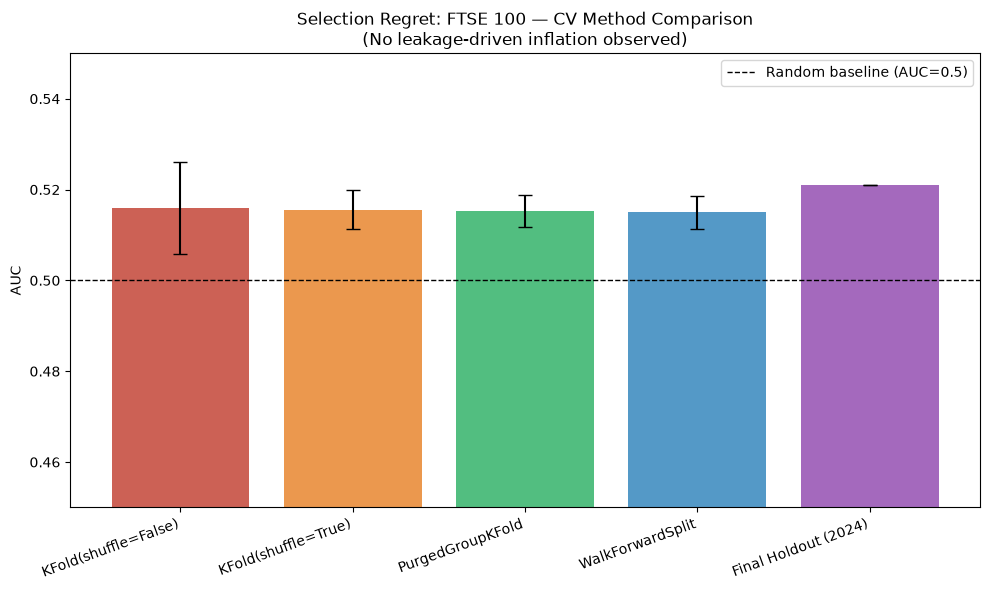


Plot saved as ftse_selection_regret.png


In [29]:
# Step 9: Visualize the results

fig, ax = plt.subplots(figsize=(10, 6))

methods = [*results_df['method'].tolist(), 'Final Holdout (2024)']
means = [*results_df['mean_auc'].tolist(), holdout_auc]
stds = [*results_df['std_auc'].tolist(), 0]

colors = ['#c0392b', '#e67e22', '#27ae60', '#2980b9', '#8e44ad']

bars = ax.bar(methods, means, yerr=stds, capsize=5, color=colors, alpha=0.8)
ax.axhline(0.5, color='black', linestyle='--', linewidth=1, label='Random baseline (AUC=0.5)')
ax.set_ylabel('AUC')
ax.set_title('Selection Regret: FTSE 100 — CV Method Comparison\n(No leakage-driven inflation observed)')
ax.set_ylim(0.45, 0.55)
ax.legend()
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('ftse_selection_regret.png', dpi=150)
plt.show()

print("\nPlot saved as ftse_selection_regret.png")